# Simulated Driving Agent Behavior (Genetic Algorithm)

## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time

# Styling
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Track Geometry and Circuit Generation

In [2]:
# Generate parametric racetrack
N_PTS = 60
theta = np.linspace(0, 2 * np.pi, N_PTS, endpoint=False)
r = 100.0 + 30.0 * np.sin(2 * theta) + 15.0 * np.cos(3 * theta)
cx = r * np.cos(theta)
cy = r * np.sin(theta)
checkpoints = np.column_stack([cx, cy])

# Calculate tangent and normal vectors for track boundaries
dx = np.gradient(cx)
dy = np.gradient(cy)
norm = np.sqrt(dx**2 + dy**2)
nx = -dy / norm
ny = dx / norm

TRACK_WIDTH = 28.0
outer_pts = np.column_stack([cx + nx * (TRACK_WIDTH / 2), cy + ny * (TRACK_WIDTH / 2)])
inner_pts = np.column_stack([cx - nx * (TRACK_WIDTH / 2), cy - ny * (TRACK_WIDTH / 2)])

# Wall boundary line segments: [p1, p2]
wall_p1 = np.vstack([outer_pts, inner_pts])
wall_p2 = np.vstack([np.roll(outer_pts, -1, axis=0), np.roll(inner_pts, -1, axis=0)])

START_POS = np.array([cx[0], cy[0]], dtype=float)
START_ANGLE = np.arctan2(dy[0], dx[0])

print(f"Track successfully generated:")
print(f"  Checkpoints:      {len(checkpoints)}")
print(f"  Wall Segments:    {len(wall_p1)} ({len(outer_pts)} outer + {len(inner_pts)} inner)")
print(f"  Track Width:      {TRACK_WIDTH} units")
print(f"  Starting Pos:     ({START_POS[0]:.2f}, {START_POS[1]:.2f}) | Angle: {np.degrees(START_ANGLE):.1f}°")

Track successfully generated:
  Checkpoints:      60
  Wall Segments:    120 (60 outer + 60 inner)
  Track Width:      28.0 units
  Starting Pos:     (115.00, 0.00) | Angle: 69.0°


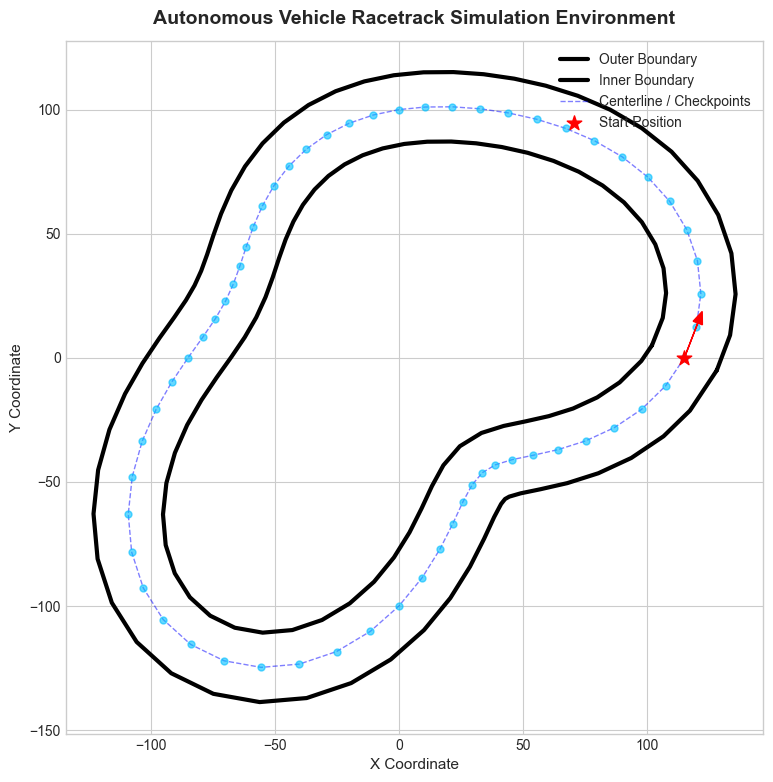

In [3]:
# Plot Racetrack Environment
plt.figure(figsize=(9, 9))
plt.plot(np.append(outer_pts[:, 0], outer_pts[0, 0]), np.append(outer_pts[:, 1], outer_pts[0, 1]), 'k-', lw=3, label='Outer Boundary')
plt.plot(np.append(inner_pts[:, 0], inner_pts[0, 0]), np.append(inner_pts[:, 1], inner_pts[0, 1]), 'k-', lw=3, label='Inner Boundary')
plt.plot(np.append(cx, cx[0]), np.append(cy, cy[0]), 'b--', lw=1, alpha=0.5, label='Centerline / Checkpoints')
plt.scatter(checkpoints[:, 0], checkpoints[:, 1], c='deepskyblue', s=25, alpha=0.6, zorder=3)

# Mark Start Line
plt.scatter(START_POS[0], START_POS[1], c='red', s=120, marker='*', zorder=5, label='Start Position')
arrow_len = 15.0
plt.arrow(START_POS[0], START_POS[1], arrow_len * np.cos(START_ANGLE), arrow_len * np.sin(START_ANGLE),
          head_width=4, head_length=5, fc='red', ec='red', zorder=5)

plt.title('Autonomous Vehicle Racetrack Simulation Environment', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('X Coordinate', fontsize=11)
plt.ylabel('Y Coordinate', fontsize=11)
plt.legend(loc='upper right')
plt.axis('equal')
plt.show()

## 3. LIDAR Sensor Raycasting System

In [4]:
SENSOR_ANGLES = np.array([-np.pi/3, -np.pi/6, 0.0, np.pi/6, np.pi/3])
MAX_SENSOR_DIST = 60.0

# Prepare static boundary arrays for vectorized cross-product intersection
v1 = wall_p1[np.newaxis, :, :] # shape (1, N_segments, 2)
v2 = wall_p2[np.newaxis, :, :]
v12 = v2 - v1

def compute_sensor_distances(car_positions, car_angles):
    """
    Vectorized raycast calculation for multiple cars simultaneously.
    car_positions: (N_cars, 2)
    car_angles: (N_cars,)
    Returns: (N_cars, 5) array of detected wall distances
    """
    N_cars = len(car_positions)
    ray_origins = []
    ray_dirs = []
    for i in range(N_cars):
        pos = car_positions[i]
        angle = car_angles[i]
        for sa in SENSOR_ANGLES:
            ray_origins.append(pos)
            ang = angle + sa
            ray_dirs.append([np.cos(ang), np.sin(ang)])
            
    ro = np.array(ray_origins)[:, np.newaxis, :] # (N_cars*5, 1, 2)
    rd = np.array(ray_dirs)[:, np.newaxis, :]    # (N_cars*5, 1, 2)

    # 2D Cross product
    denom = rd[:, :, 0] * v12[:, :, 1] - rd[:, :, 1] * v12[:, :, 0]
    denom_safe = np.where(np.abs(denom) < 1e-8, 1e-8, denom)
    diff = v1 - ro
    t = (diff[:, :, 0] * v12[:, :, 1] - diff[:, :, 1] * v12[:, :, 0]) / denom_safe
    u = (diff[:, :, 0] * rd[:, :, 1] - diff[:, :, 1] * rd[:, :, 0]) / denom_safe

    valid = (np.abs(denom) >= 1e-8) & (t >= 0.0) & (t <= MAX_SENSOR_DIST) & (u >= 0.0) & (u <= 1.0)
    t_valid = np.where(valid, t, MAX_SENSOR_DIST)
    min_dist = np.min(t_valid, axis=1) # (N_cars * 5,)
    return min_dist.reshape((N_cars, 5))

# Test raycaster on start car position
test_dists = compute_sensor_distances(np.array([START_POS]), np.array([START_ANGLE]))[0]
print("Sensor distances at start line (normalized to [0, 1]):")
labels = ['Far-Left (-60°)', 'Left (-30°)', 'Front (0°)', 'Right (+30°)', 'Far-Right (+60°)']
for lbl, d in zip(labels, test_dists):
    print(f"  {lbl:18s}: {d:.2f} units (Normalized: {d/MAX_SENSOR_DIST:.2f})")

Sensor distances at start line (normalized to [0, 1]):
  Far-Left (-60°)   : 16.11 units (Normalized: 0.27)
  Left (-30°)       : 24.79 units (Normalized: 0.41)
  Front (0°)        : 49.15 units (Normalized: 0.82)
  Right (+30°)      : 60.00 units (Normalized: 1.00)
  Far-Right (+60°)  : 16.09 units (Normalized: 0.27)


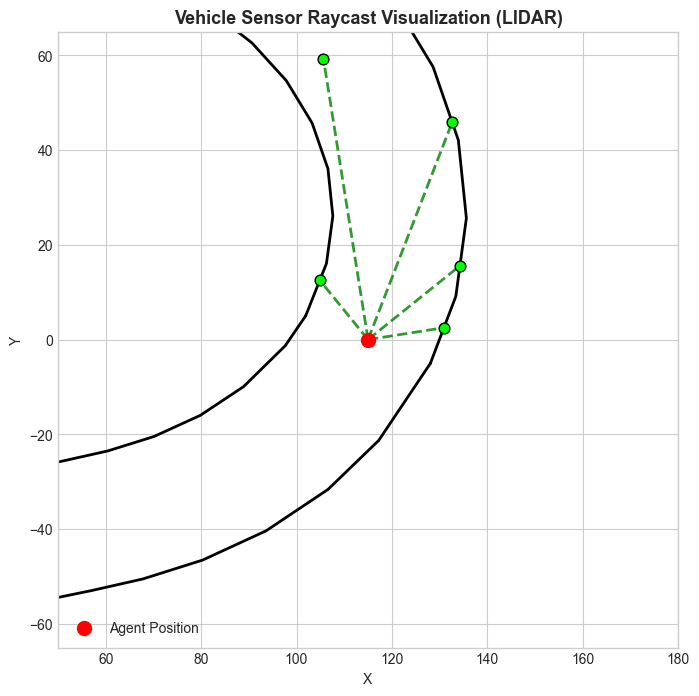

In [5]:
# Visualize Car Raycasts at Start Position
plt.figure(figsize=(8, 8))
plt.plot(np.append(outer_pts[:, 0], outer_pts[0, 0]), np.append(outer_pts[:, 1], outer_pts[0, 1]), 'k-', lw=2)
plt.plot(np.append(inner_pts[:, 0], inner_pts[0, 0]), np.append(inner_pts[:, 1], inner_pts[0, 1]), 'k-', lw=2)

# Plot car position
plt.scatter(START_POS[0], START_POS[1], c='red', s=100, zorder=5, label='Agent Position')

# Plot rays
for sa, d in zip(SENSOR_ANGLES, test_dists):
    ray_end = START_POS + d * np.array([np.cos(START_ANGLE + sa), np.sin(START_ANGLE + sa)])
    plt.plot([START_POS[0], ray_end[0]], [START_POS[1], ray_end[1]], 'g--', lw=2, alpha=0.8)
    plt.scatter(ray_end[0], ray_end[1], c='lime', edgecolors='k', s=60, zorder=4)

plt.title('Vehicle Sensor Raycast Visualization (LIDAR)', fontsize=13, fontweight='bold')
plt.xlim(START_POS[0] - 65, START_POS[0] + 65)
plt.ylim(START_POS[1] - 65, START_POS[1] + 65)
plt.xlabel('X')
plt.ylabel('Y')
plt.legend(loc='lower left')
plt.show()

## 4. Neural Network Controller Architecture

In [6]:
class AgentBrain:
    """Neural Network Controller for the driving agent."""
    def __init__(self, chromosome=None):
        if chromosome is None:
            # Initialize with small random weights
            self.w1 = np.random.randn(5, 8) * 0.5
            self.b1 = np.zeros(8)
            self.w2 = np.random.randn(8, 1) * 0.5
            self.b2 = np.zeros(1)
        else:
            self.set_chromosome(chromosome)

    def get_chromosome(self):
        """Flatten network parameters into a 1D genetic chromosome."""
        return np.concatenate([self.w1.flatten(), self.b1, self.w2.flatten(), self.b2])

    def set_chromosome(self, chromosome):
        """Unpack 1D chromosome into layer weights and biases."""
        self.w1 = chromosome[0:40].reshape((5, 8))
        self.b1 = chromosome[40:48]
        self.w2 = chromosome[48:56].reshape((8, 1))
        self.b2 = chromosome[56:57]

    def forward(self, inputs):
        """Forward pass: inputs (5,) -> steering output [-1, 1]."""
        h = np.tanh(inputs @ self.w1 + self.b1)
        out = np.tanh(h @ self.w2 + self.b2)
        return float(out[0])

# Verify chromosome structure
sample_brain = AgentBrain()
chrom = sample_brain.get_chromosome()
print(f"Agent Brain initialized.")
print(f"Total parameters (Chromosome length): {len(chrom)} genes")

Agent Brain initialized.
Total parameters (Chromosome length): 57 genes


## 5. Vehicle Kinematics and Fitness Function

In [7]:
class VehicleAgent:
    """Simulated vehicle agent navigating the racetrack."""
    def __init__(self, brain=None):
        self.brain = brain if brain is not None else AgentBrain()
        self.reset()

    def reset(self):
        self.pos = START_POS.copy()
        self.angle = float(START_ANGLE)
        self.speed = 3.5
        self.alive = True
        self.cp_idx = 0
        self.dist_traveled = 0.0
        self.fitness = 0.0
        self.trajectory = [self.pos.copy()]

    def step(self, sensor_readings):
        if not self.alive:
            return

        # Check collision with barriers
        if np.min(sensor_readings) < 2.5:
            self.alive = False
            return

        # Normalized sensor inputs [0, 1]
        norm_inputs = sensor_readings / MAX_SENSOR_DIST
        steer = self.brain.forward(norm_inputs) * 0.22 # max steering deflection

        # Kinematic update
        self.angle += steer
        self.pos += np.array([np.cos(self.angle), np.sin(self.angle)]) * self.speed
        self.dist_traveled += self.speed
        self.trajectory.append(self.pos.copy())

        # Checkpoint check
        next_cp = checkpoints[(self.cp_idx + 1) % N_PTS]
        if np.linalg.norm(self.pos - next_cp) < 22.0:
            self.cp_idx += 1

        # Update fitness
        self.fitness = (self.cp_idx * 150.0) + (self.dist_traveled * 0.2)

print("VehicleAgent class defined.")

VehicleAgent class defined.


## 6. Genetic Algorithm Operators (Selection, Crossover, Mutation)

In [8]:
def tournament_selection(population, fitnesses, tournament_size=3):
    """Selects a parent using tournament selection among top candidates."""
    top_indices = np.argsort(fitnesses)[::-1][:12]
    selected_idx = np.random.choice(top_indices, size=tournament_size)
    best_candidate = selected_idx[np.argmax([fitnesses[i] for i in selected_idx])]
    return population[best_candidate]

def crossover(parent1_chrom, parent2_chrom):
    """Uniform crossover between two parent chromosomes."""
    mask = np.random.rand(len(parent1_chrom)) > 0.5
    child_chrom = np.where(mask, parent1_chrom, parent2_chrom)
    return child_chrom

def mutate(chromosome, mutation_rate=0.15, mutation_scale=0.25):
    """Applies Gaussian mutation to chromosome genes."""
    mutated = chromosome.copy()
    mask = np.random.rand(len(mutated)) < mutation_rate
    mutated[mask] += np.random.randn(np.sum(mask)) * mutation_scale
    return mutated

print("Genetic operators (Selection, Elitism, Crossover, Mutation) defined.")

Genetic operators (Selection, Elitism, Crossover, Mutation) defined.


## 7. Evolutionary Training Loop

In [9]:
POP_SIZE = 25
GENERATIONS = 15
MAX_STEPS = 350
ELITE_COUNT = 3

population = [VehicleAgent() for _ in range(POP_SIZE)]

history_best_fitness = []
history_avg_fitness = []
history_best_cp = []
generation_trajectories = {} # to store trajectories for generations 1, 5, 10, 15

print("==========================================================================")
print(f" Starting Neuroevolutionary Training: {POP_SIZE} Agents x {GENERATIONS} Generations")
print("==========================================================================")

t_start = time.time()

for gen in range(1, GENERATIONS + 1):
    # Reset all agents
    for agent in population:
        agent.reset()

    # Step simulation
    for step in range(MAX_STEPS):
        alive_agents = [a for a in population if a.alive]
        if not alive_agents:
            break

        positions = np.array([a.pos for a in alive_agents])
        angles = np.array([a.angle for a in alive_agents])
        sensor_readings = compute_sensor_distances(positions, angles)

        for i, agent in enumerate(alive_agents):
            agent.step(sensor_readings[i])

    fitnesses = [a.fitness for a in population]
    best_idx = int(np.argmax(fitnesses))
    best_fit = fitnesses[best_idx]
    avg_fit = float(np.mean(fitnesses))
    best_cp = population[best_idx].cp_idx

    history_best_fitness.append(best_fit)
    history_avg_fitness.append(avg_fit)
    history_best_cp.append(best_cp)

    # Save trajectory for visualization
    if gen in [1, 5, 10, 15]:
        generation_trajectories[gen] = [p.copy() for p in population[best_idx].trajectory]

    laps_completed = best_cp / N_PTS
    print(f"Gen {gen:2d}/{GENERATIONS} | Best Fitness: {best_fit:7.1f} | Avg Fitness: {avg_fit:6.1f} | Best Checkpoints: {best_cp:3d} ({laps_completed:.1f} Laps)")

    # Evolve population for next generation
    if gen < GENERATIONS:
        sorted_indices = np.argsort(fitnesses)[::-1]
        new_population = []

        # 1. Elitism: preserve top performers
        for e in range(ELITE_COUNT):
            elite_brain = AgentBrain(population[sorted_indices[e]].brain.get_chromosome().copy())
            new_population.append(VehicleAgent(elite_brain))

        # 2. Reproduction: Crossover + Mutation
        while len(new_population) < POP_SIZE:
            p1 = tournament_selection(population, fitnesses)
            p2 = tournament_selection(population, fitnesses)
            child_chrom = crossover(p1.brain.get_chromosome(), p2.brain.get_chromosome())
            mutated_chrom = mutate(child_chrom)
            new_population.append(VehicleAgent(AgentBrain(mutated_chrom)))

        population = new_population

elapsed = time.time() - t_start
print(f"\nTraining successfully finished in {elapsed:.2f} seconds!")

 Starting Neuroevolutionary Training: 25 Agents x 15 Generations
Gen  1/15 | Best Fitness:  8373.9 | Avg Fitness: 1463.1 | Best Checkpoints:  55 (0.9 Laps)


Gen  2/15 | Best Fitness: 16595.0 | Avg Fitness: 4061.4 | Best Checkpoints: 109 (1.8 Laps)
Gen  3/15 | Best Fitness: 16745.0 | Avg Fitness: 6524.6 | Best Checkpoints: 110 (1.8 Laps)


Gen  4/15 | Best Fitness: 17345.0 | Avg Fitness: 8218.3 | Best Checkpoints: 114 (1.9 Laps)


Gen  5/15 | Best Fitness: 17495.0 | Avg Fitness: 14228.2 | Best Checkpoints: 115 (1.9 Laps)


Gen  6/15 | Best Fitness: 17495.0 | Avg Fitness: 12698.2 | Best Checkpoints: 115 (1.9 Laps)


...

Gen 11/15 | Best Fitness: 17795.0 | Avg Fitness: 11384.9 | Best Checkpoints: 117 (1.9 Laps)


Gen 12/15 | Best Fitness: 17795.0 | Avg Fitness: 12060.6 | Best Checkpoints: 117 (1.9 Laps)


Gen 13/15 | Best Fitness: 17795.0 | Avg Fitness: 10063.7 | Best Checkpoints: 117 (1.9 Laps)


Gen 14/15 | Best Fitness: 17795.0 | Avg Fitness: 10027.8 | Best Checkpoints: 117 (1.9 Laps)


Gen 15/15 | Best Fitness: 17795.0 | Avg Fitness: 10787.5 | Best Checkpoints: 117 (1.9 Laps)

Training successfully finished in 4.93 seconds!


## 8. Learning Curves and Fitness Progression

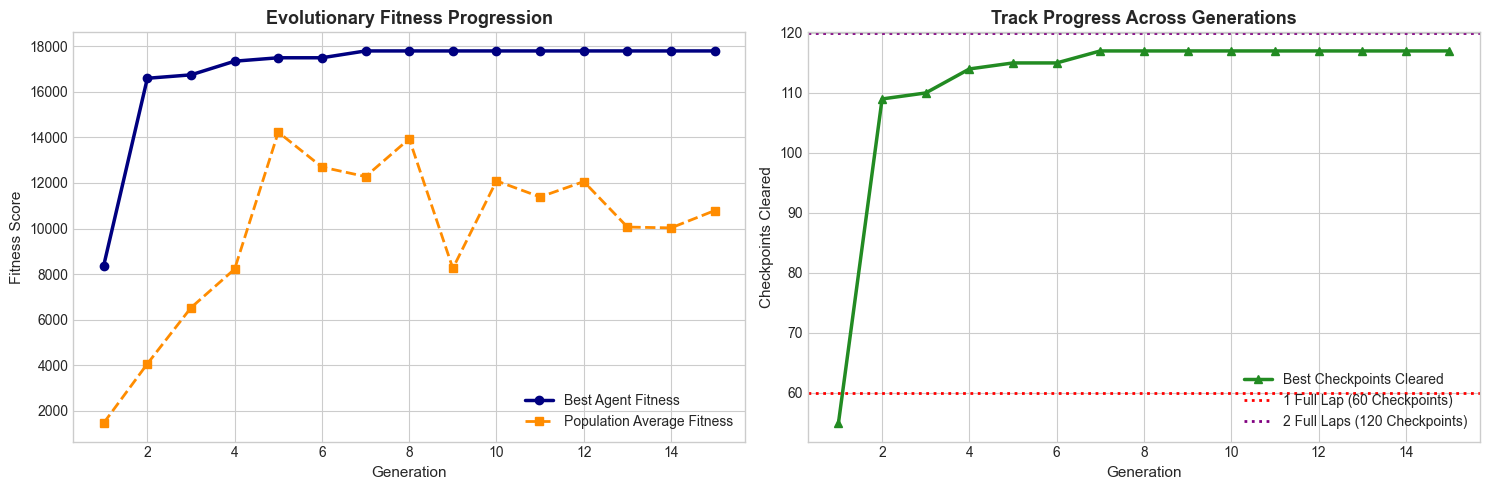

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
gens = range(1, GENERATIONS + 1)

# Fitness Evolution Plot
axes[0].plot(gens, history_best_fitness, 'o-', color='navy', lw=2.5, label='Best Agent Fitness')
axes[0].plot(gens, history_avg_fitness, 's--', color='darkorange', lw=2, label='Population Average Fitness')
axes[0].set_title('Evolutionary Fitness Progression', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Generation', fontsize=11)
axes[0].set_ylabel('Fitness Score', fontsize=11)
axes[0].legend(loc='lower right')

# Checkpoints Cleared Plot
axes[1].plot(gens, history_best_cp, '^-', color='forestgreen', lw=2.5, label='Best Checkpoints Cleared')
axes[1].axhline(y=N_PTS, color='red', linestyle=':', lw=2, label='1 Full Lap (60 Checkpoints)')
axes[1].axhline(y=2*N_PTS, color='purple', linestyle=':', lw=2, label='2 Full Laps (120 Checkpoints)')
axes[1].set_title('Track Progress Across Generations', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Generation', fontsize=11)
axes[1].set_ylabel('Checkpoints Cleared', fontsize=11)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

In [11]:
# Summary table of training progression
summary_data = {
    'Generation': list(gens),
    'Best Fitness': [round(f, 1) for f in history_best_fitness],
    'Avg Fitness': [round(f, 1) for f in history_avg_fitness],
    'Checkpoints': history_best_cp,
    'Laps Completed': [round(cp / N_PTS, 2) for cp in history_best_cp]
}
summary_df = pd.DataFrame(summary_data)
print("=== Genetic Algorithm Training Summary Table ===")
summary_df

=== Genetic Algorithm Training Summary Table ===


,Generation,Best Fitness,Avg Fitness,Checkpoints,Laps Completed
0,1,8373.9,1463.1,55,0.92
1,2,16595.0,4061.4,109,1.82
2,3,16745.0,6524.6,110,1.83
3,4,17345.0,8218.3,114,1.90
4,5,17495.0,14228.2,115,1.92
5,6,17495.0,12698.2,115,1.92
6,7,17795.0,12279.0,117,1.95
7,8,17795.0,13937.4,117,1.95
8,9,17795.0,8251.6,117,1.95
9,10,17795.0,12090.6,117,1.95


## 9. Trajectory Comparison Across Generations

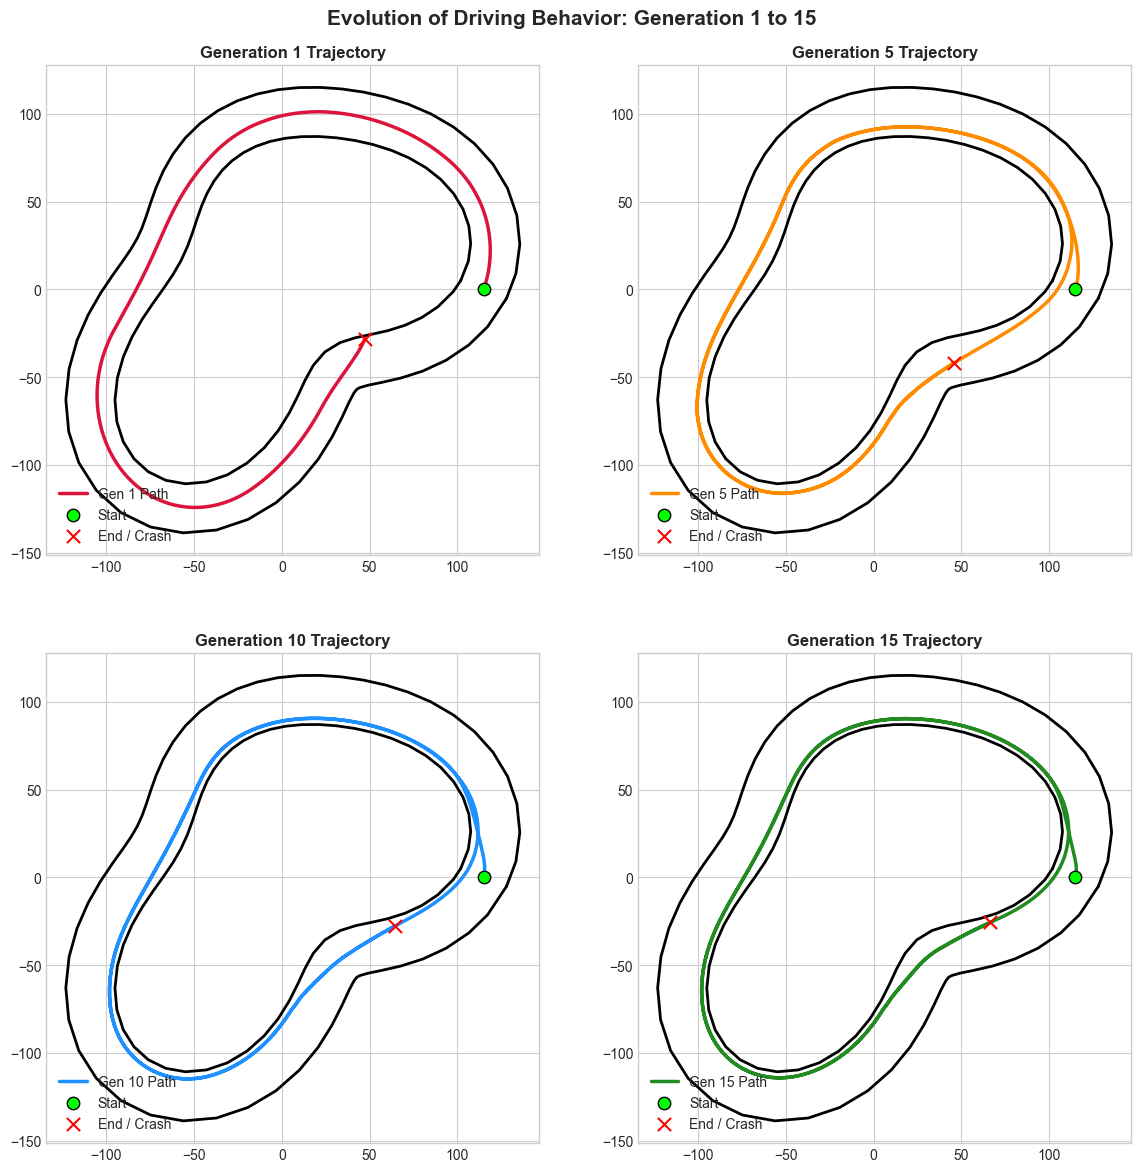

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

track_outer_closed = np.vstack([outer_pts, outer_pts[0]])
track_inner_closed = np.vstack([inner_pts, inner_pts[0]])

colors = ['crimson', 'darkorange', 'dodgerblue', 'forestgreen']

for idx, (gen_num, traj) in enumerate(generation_trajectories.items()):
    ax = axes[idx]
    traj = np.array(traj)

    # Draw track boundaries
    ax.plot(track_outer_closed[:, 0], track_outer_closed[:, 1], 'k-', lw=2)
    ax.plot(track_inner_closed[:, 0], track_inner_closed[:, 1], 'k-', lw=2)

    # Draw agent path
    ax.plot(traj[:, 0], traj[:, 1], color=colors[idx], lw=2.5, label=f'Gen {gen_num} Path')
    ax.scatter(traj[0, 0], traj[0, 1], c='lime', edgecolors='k', s=80, zorder=5, label='Start')
    ax.scatter(traj[-1, 0], traj[-1, 1], c='red', marker='x', s=90, zorder=5, label='End / Crash')

    ax.set_title(f'Generation {gen_num} Trajectory', fontsize=12, fontweight='bold')
    ax.legend(loc='lower left')
    ax.axis('equal')

plt.suptitle('Evolution of Driving Behavior: Generation 1 to 15', fontsize=15, fontweight='bold', y=0.92)
plt.show()

## 10. Champion Agent Evaluation & Network Weights

In [13]:
# Select Champion Agent
champion = population[int(np.argmax([a.fitness for a in population]))]
champion.reset()

for step in range(MAX_STEPS):
    if not champion.alive:
        break
    readings = compute_sensor_distances(np.array([champion.pos]), np.array([champion.angle]))
    champion.step(readings[0])

print("=== Champion Agent Evaluation Report ===")
print(f"  Status:              {'Active / Completed' if champion.alive else 'Crashed'}")
print(f"  Fitness Score:       {champion.fitness:.1f}")
print(f"  Checkpoints Cleared: {champion.cp_idx} (~{champion.cp_idx / N_PTS:.2f} Laps)")
print(f"  Distance Traveled:   {champion.dist_traveled:.1f} units")
print(f"  Trajectory Points:   {len(champion.trajectory)} steps")

=== Champion Agent Evaluation Report ===
  Status:              Active / Completed
  Fitness Score:       17795.0
  Checkpoints Cleared: 117 (~1.95 Laps)
  Distance Traveled:   1225.0 units
  Trajectory Points:   351 steps


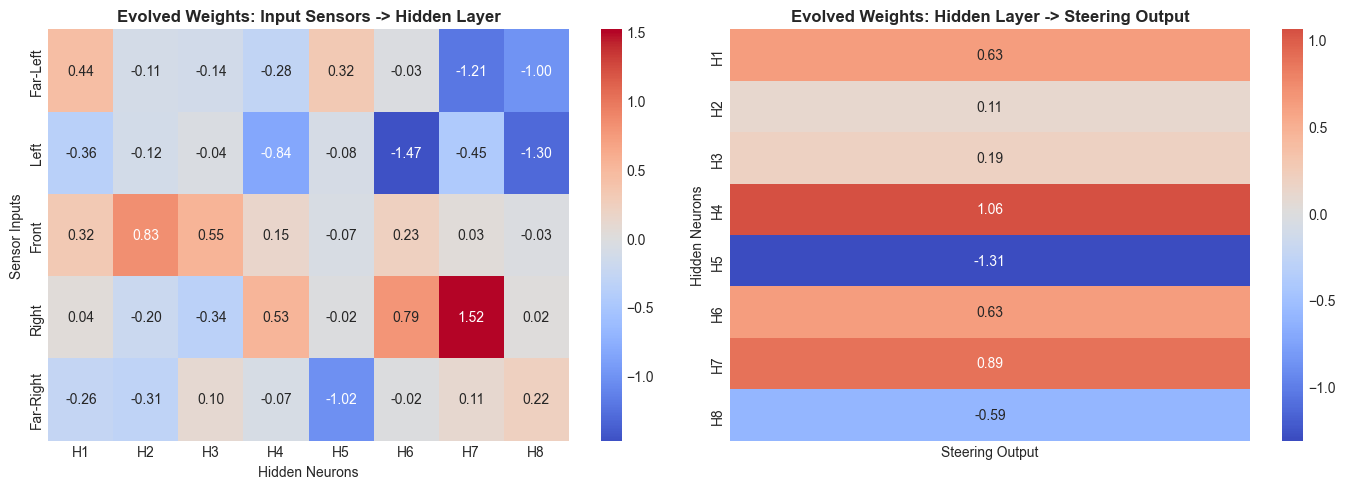

In [14]:
# Visualizing Evolved Neural Network Weights
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Input -> Hidden Layer Weights
sns.heatmap(champion.brain.w1, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=[f'H{i+1}' for i in range(8)],
            yticklabels=['Far-Left', 'Left', 'Front', 'Right', 'Far-Right'],
            ax=axes[0])
axes[0].set_title('Evolved Weights: Input Sensors -> Hidden Layer', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hidden Neurons')
axes[0].set_ylabel('Sensor Inputs')

# Hidden -> Output Layer Weights
sns.heatmap(champion.brain.w2, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=['Steering Output'],
            yticklabels=[f'H{i+1}' for i in range(8)],
            ax=axes[1])
axes[1].set_title('Evolved Weights: Hidden Layer -> Steering Output', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Hidden Neurons')

plt.tight_layout()
plt.show()

## 11. Conclusion